In [8]:
import os
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đường dẫn tới thư mục dữ liệu thô
RAW_DATA_DIR = "../data/raw"

# 2. Thống kê thông tin tất cả các ảnh
data_info = []

for split in ['Training', 'Testing']:
    split_path = os.path.join(RAW_DATA_DIR, split)
    if not os.path.exists(split_path):
        continue
        
    for label in os.listdir(split_path):
        label_path = os.path.join(split_path, label)
        if os.path.isdir(label_path):
            for file in os.listdir(label_path):
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(label_path, file)
                    try:
                        with Image.open(img_path) as img:
                            w, h = img.size
                            mode = img.mode
                        data_info.append({
                            'path': img_path,
                            'split': split,
                            'label': label,
                            'width': w,
                            'height': h,
                            'mode': mode
                        })
                    except Exception as e:
                        print(f" Ảnh lỗi không đọc được: {img_path} - {e}")
# Chuyển thành DataFrame để dễ phân tích
df = pd.DataFrame(data_info)
print(f"Tổng số ảnh đọc thành công: {len(df)}")
print(df.head())

Tổng số ảnh đọc thành công: 7200
                                         path     split   label  width  \
0     ../data/raw\Training\glioma\Tr-gl_1.jpg  Training  glioma    512   
1    ../data/raw\Training\glioma\Tr-gl_10.jpg  Training  glioma    512   
2   ../data/raw\Training\glioma\Tr-gl_100.jpg  Training  glioma    512   
3  ../data/raw\Training\glioma\Tr-gl_1000.jpg  Training  glioma    512   
4  ../data/raw\Training\glioma\Tr-gl_1001.jpg  Training  glioma    512   

   height mode  
0     512    L  
1     512    L  
2     512    L  
3     512    L  
4     512    L  


In [5]:
import os
from PIL import Image

# Đường dẫn tới thư mục data thô
RAW_DATA_DIR = "../data/raw"

corrupted_files = []
total_checked = 0

print(" Đang quét và kiểm tra toàn bộ file ảnh...")

for root, dirs, files in os.walk(RAW_DATA_DIR):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
            total_checked += 1
            file_path = os.path.join(root, file)
            
            # 1. Kiểm tra file bị 0 byte (file rỗng)
            if os.path.getsize(file_path) == 0:
                print(f" File rỗng (0 bytes): {file_path}")
                corrupted_files.append(file_path)
                continue

            # 2. Thử giải mã toàn bộ dữ liệu pixel của ảnh
            try:
                with Image.open(file_path) as img:
                    img.verify() # Kiểm tra cấu trúc file
                
                # Mở lại để load toàn bộ pixel (tránh trường hợp ảnh bị lỗi đoạn đuôi)
                with Image.open(file_path) as img:
                    img.load()
            except Exception as e:
                print(f" File hỏng không đọc được: {file_path} | Lỗi: {e}")
                corrupted_files.append(file_path)

# --- BÁO CÁO KẾT QUẢ ---
print("\n" + "="*40)
print(f" TỔNG KẾT:")
print(f"- Tổng số ảnh đã kiểm tra: {total_checked}")
print(f"- Số lượng ảnh lỗi: {len(corrupted_files)}")

if corrupted_files:
    print("\n Danh sách các file lỗi phát hiện được:")
    for path in corrupted_files:
        print(f"  └─ {path}")
else:
    print(" Tất cả ảnh trong dataset đều nguyên vẹn và hợp lệ 100%.")

 Đang quét và kiểm tra toàn bộ file ảnh...

 TỔNG KẾT:
- Tổng số ảnh đã kiểm tra: 7200
- Số lượng ảnh lỗi: 0
 Tất cả ảnh trong dataset đều nguyên vẹn và hợp lệ 100%.


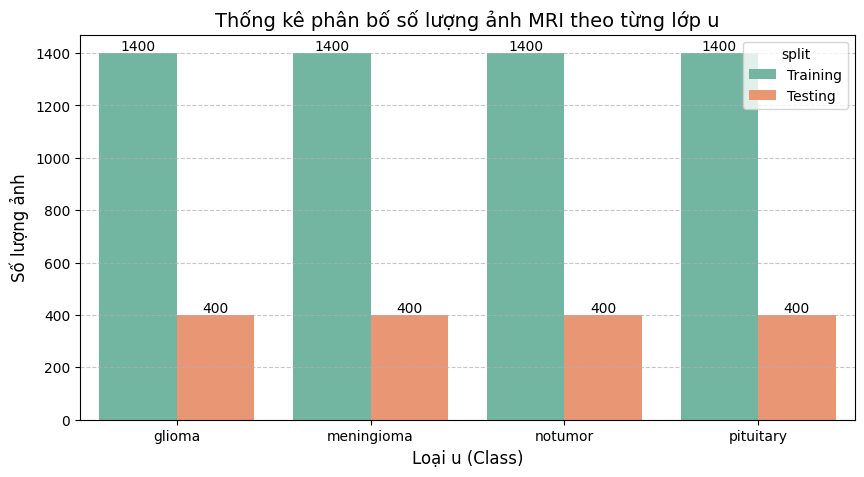


--- THỐNG KÊ KÍCH THƯỚC ẢNH ---
             width       height
count  7200.000000  7200.000000
mean    453.302917   456.899167
std     130.048964   124.402496
min     150.000000   167.000000
25%     442.000000   449.000000
50%     512.000000   512.000000
75%     512.000000   512.000000
max    1375.000000  1446.000000


In [9]:

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='label', hue='split', palette='Set2')
plt.title("Thống kê phân bố số lượng ảnh MRI theo từng lớp u", fontsize=14)
plt.xlabel("Loại u (Class)", fontsize=12)
plt.ylabel("Số lượng ảnh", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=10)

plt.show()

# 4. Kiểm tra kích thước ảnh trung bình
print("\n--- THỐNG KÊ KÍCH THƯỚC ẢNH ---")
print(df[['width', 'height']].describe())